# Notebook 05 — Geospatial Delay Heatmap
**Project:** Vendor Risk Scorecard & Delivery Delay Root Cause System  
**Input:** `data/processed/orders_with_rootcause.csv` + `data/raw/olist_geolocation_dataset.csv`  
**Output:** `outputs/delay_heatmap_customer.html` + `outputs/delay_heatmap_seller.html`

---
### What we do in this notebook

We visualise two geographic questions:

1. **Where do customers experience late deliveries?** (customer state heatmap)
2. **Where are the high-risk vendors concentrated?** (seller state choropleth)

These maps are the visual showstopper of the project — interactive HTML files  
you can open in any browser and include in your GitHub README and portfolio.

### Why geospatial analysis matters here
5.8% of delays were classified as geographic — structural zone problems.  
These can't be fixed by warning vendors or renegotiating carriers.  
They need a different intervention: adjusted delivery estimates, surcharges, or  
dedicated last-mile partnerships. The map shows where those zones are.

---
## Cell 1 — Install and mount

In [19]:
# ── Run this cell first every session ────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE    = '/content/drive/MyDrive/vendor-risk-scorecard/'
RAW     = BASE + 'data/raw/'
PROC    = BASE + 'data/processed/'
OUTPUTS = BASE + 'outputs/'

# Reload all key dataframes
orders    = pd.read_csv(PROC + 'orders_with_rootcause.csv')
scorecard = pd.read_csv(PROC + 'vendor_scorecard.csv')
geo       = pd.read_csv(RAW  + 'olist_geolocation_dataset.csv')

# Rebuild geo_ref
geo_ref = (
    geo.groupby('geolocation_zip_code_prefix')
    .agg(lat=('geolocation_lat','median'), lng=('geolocation_lng','median'), state=('geolocation_state','first'))
    .reset_index().rename(columns={'geolocation_zip_code_prefix':'zip_prefix'})
)
geo_ref = geo_ref[(geo_ref['lat'].between(-34,6)) & (geo_ref['lng'].between(-74,-28))]

# Rebuild scorecard with zip — explicit check
sellers_raw = pd.read_csv(RAW + 'olist_sellers_dataset.csv')[['seller_id','seller_zip_code_prefix']]
scorecard   = scorecard.merge(sellers_raw, on='seller_id', how='left')

# Verify it worked before continuing
assert 'seller_zip_code_prefix' in scorecard.columns, "ZIP merge failed!"
print(f'seller_zip_code_prefix present: True')
print(f'Null zips: {scorecard["seller_zip_code_prefix"].isnull().sum()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
seller_zip_code_prefix present: True
Null zips: 0


---
## Cell 2 — Load data

In [20]:
sellers_raw = pd.read_csv(RAW + 'olist_sellers_dataset.csv')[['seller_id', 'seller_zip_code_prefix']]
scorecard   = pd.read_csv(PROC + 'vendor_scorecard.csv')
scorecard   = scorecard.merge(sellers_raw, on='seller_id', how='left')

print('seller_zip_code_prefix' in scorecard.columns)   # must print True
print(scorecard['seller_zip_code_prefix'].isnull().sum())  # ideally 0 or very small
print(scorecard.shape)

True
0
(1226, 18)


In [21]:
seller_geo = scorecard.merge(
    geo_ref[['zip_prefix', 'lat', 'lng']],
    left_on='seller_zip_code_prefix',
    right_on='zip_prefix',
    how='left'
).dropna(subset=['lat', 'lng'])

print(f'Vendors with coordinates: {len(seller_geo):,}')
print(seller_geo['risk_tier'].value_counts().to_string())

Vendors with coordinates: 1,223
risk_tier
Green    855
Amber    245
Red      123


In [22]:
# Check what columns vendor_features actually has
vf = pd.read_csv(PROC + 'vendor_features.csv')
print('vendor_features columns:')
print(vf.columns.tolist())

vendor_features columns:
['seller_id', 'total_orders', 'otd_rate', 'late_rate', 'avg_processing_days', 'p75_processing_days', 'median_processing_days', 'avg_carrier_days', 'avg_delay_days', 'sla_breach_rate', 'seller_state']


In [23]:
# Pull zip from raw sellers file
sellers_raw = pd.read_csv(RAW + 'olist_sellers_dataset.csv')
print('sellers columns:', sellers_raw.columns.tolist())
print(sellers_raw.head(2))

sellers columns: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']
                          seller_id  seller_zip_code_prefix seller_city  \
0  3442f8959a84dea7ee197c632cb2df15                   13023    campinas   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844  mogi guacu   

  seller_state  
0           SP  
1           SP  


In [24]:
# Fix: pull seller_zip_code_prefix from raw sellers file
sellers_raw = pd.read_csv(RAW + 'olist_sellers_dataset.csv')[['seller_id', 'seller_zip_code_prefix']]
scorecard   = pd.read_csv(PROC + 'vendor_scorecard.csv')
scorecard   = scorecard.merge(sellers_raw, on='seller_id', how='left')

print(f'Scorecard shape: {scorecard.shape}')
print(f'seller_zip_code_prefix nulls: {scorecard["seller_zip_code_prefix"].isnull().sum()}')
print(f'Sample:')
print(scorecard[['seller_id','seller_zip_code_prefix','seller_state','risk_tier']].head(3))

Scorecard shape: (1226, 18)
seller_zip_code_prefix nulls: 0
Sample:
                          seller_id  seller_zip_code_prefix seller_state  \
0  b1b3948701c5c72445495bd161b83a4c                    3390           SP   
1  54965bbe3e4f07ae045b90b0b8541f52                   85851           PR   
2  ad781527c93d00d89a11eecd9dcad7c1                   15015           SP   

  risk_tier  
0       Red  
1       Red  
2       Red  


In [25]:
# Orders with root cause
orders = pd.read_csv(PROC + 'orders_with_rootcause.csv')

# Vendor scorecard
scorecard = pd.read_csv(PROC + 'vendor_scorecard.csv')

# Geolocation — lat/long per zip code prefix
geo = pd.read_csv(RAW + 'olist_geolocation_dataset.csv')

print(f'Orders:    {orders.shape}')
print(f'Scorecard: {scorecard.shape}')
print(f'Geo:       {geo.shape}')
print()
print('Geo columns:', geo.columns.tolist())

Orders:    (96469, 17)
Scorecard: (1226, 17)
Geo:       (1000163, 5)

Geo columns: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']


---
## Cell 3 — Prepare geolocation reference

The geolocation table has multiple lat/long entries per zip code prefix.  
We take the median per prefix to get a single representative point.

In [26]:
# Aggregate to one lat/long per zip prefix
geo_ref = (
    geo
    .groupby('geolocation_zip_code_prefix')
    .agg(
        lat   = ('geolocation_lat', 'median'),
        lng   = ('geolocation_lng', 'median'),
        state = ('geolocation_state', 'first')
    )
    .reset_index()
    .rename(columns={'geolocation_zip_code_prefix': 'zip_prefix'})
)

# Remove outlier coordinates (Brazil bounding box)
geo_ref = geo_ref[
    (geo_ref['lat'].between(-34, 6)) &
    (geo_ref['lng'].between(-74, -28))
]

print(f'Geo reference table: {len(geo_ref):,} zip prefixes')
print(f'Lat range: {geo_ref["lat"].min():.2f} to {geo_ref["lat"].max():.2f}')
print(f'Lng range: {geo_ref["lng"].min():.2f} to {geo_ref["lng"].max():.2f}')

Geo reference table: 19,008 zip prefixes
Lat range: -33.69 to 4.48
Lng range: -72.91 to -32.41


---
## Cell 4 — Map 1: Customer delay heatmap

Shows where late deliveries land geographically — customer perspective.  
Each point = one late order, intensity = concentration of delays.

In [27]:
# Get late orders only
late_orders = orders[orders['is_late'] == True].copy()

# Merge with customer zip coordinates
late_orders = late_orders.merge(
    geo_ref[['zip_prefix', 'lat', 'lng']].rename(
        columns={'zip_prefix': 'customer_zip_code_prefix',
                 'lat': 'cust_lat', 'lng': 'cust_lng'}
    ),
    on='customer_zip_code_prefix',
    how='left'
)

# Drop rows without coordinates
late_geo = late_orders.dropna(subset=['cust_lat', 'cust_lng'])
print(f'Late orders with coordinates: {len(late_geo):,} of {len(late_orders):,}')

Late orders with coordinates: 7,795 of 7,825


In [28]:
# Build the customer heatmap
# Brazil center coordinates
BRAZIL_CENTER = [-14.2, -51.9]

customer_map = folium.Map(
    location=BRAZIL_CENTER,
    zoom_start=4,
    tiles='CartoDB positron'   # clean light background
)

# Prepare heat data: [lat, lng, weight]
# Weight by delay severity — more days late = higher intensity
heat_data = [
    [row['cust_lat'], row['cust_lng'], min(row['delay_days'] / 10, 1.0)]
    for _, row in late_geo.iterrows()
]

HeatMap(
    heat_data,
    min_opacity=0.3,
    max_zoom=8,
    radius=12,
    blur=10,
    gradient={0.2: 'blue', 0.5: 'yellow', 0.8: 'orange', 1.0: 'red'}
).add_to(customer_map)

# Add title
title_html = '''
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
            background: white; padding: 8px 16px; border-radius: 6px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.3); z-index: 9999;
            font-family: Arial; font-size: 14px; font-weight: bold; color: #333;">
    Late Delivery Heatmap — Customer Locations
    <span style="font-weight:normal; font-size:11px; color:#888;"> (intensity = delay severity)</span>
</div>
'''
customer_map.get_root().html.add_child(folium.Element(title_html))

# Save
map_path = OUTPUTS + 'delay_heatmap_customer.html'
customer_map.save(map_path)
print(f'Saved: delay_heatmap_customer.html')
print('Open this file in your browser to see the interactive map.')

Saved: delay_heatmap_customer.html
Open this file in your browser to see the interactive map.


In [29]:
# Preview in Colab (renders inline)
from IPython.display import IFrame
customer_map

---
## Cell 5 — Map 2: Root cause breakdown by customer state

A choropleth-style bar chart showing which states have the highest  
concentration of each root cause type.

In [30]:
# State-level late rate and root cause breakdown
state_analysis = (
    orders
    .groupby('customer_state')
    .agg(
        total_orders      = ('order_id',        'count'),
        late_orders       = ('is_late',          'sum'),
        seller_delay      = ('root_cause',       lambda x: (x == 'seller_delay').sum()),
        carrier_delay     = ('root_cause',       lambda x: (x == 'carrier_delay').sum()),
        geographic_delay  = ('root_cause',       lambda x: (x == 'geographic_delay').sum()),
        avg_delay_days    = ('delay_days',       'mean'),
    )
    .reset_index()
)

state_analysis['late_rate_%'] = (
    state_analysis['late_orders'] / state_analysis['total_orders'] * 100
).round(1)

state_analysis = state_analysis.sort_values('late_rate_%', ascending=False)

print('State-level delivery analysis:')
print(state_analysis[['customer_state','total_orders','late_rate_%',
                       'seller_delay','carrier_delay','geographic_delay']]
      .to_string(index=False))

State-level delivery analysis:
customer_state  total_orders  late_rate_%  seller_delay  carrier_delay  geographic_delay
            AL           397         23.9            29             66                 0
            MA           717         19.7            62             77                 2
            PI           476         16.0            28             48                 0
            CE          1279         15.3            75            121                 0
            SE           335         15.2            23             28                 0
            BA          3256         14.0           158            299                 0
            RJ         12350         13.5           633           1002                29
            TO           274         12.8            21             14                 0
            PA           946         12.4            36             81                 0
            RR            41         12.2             2              3         

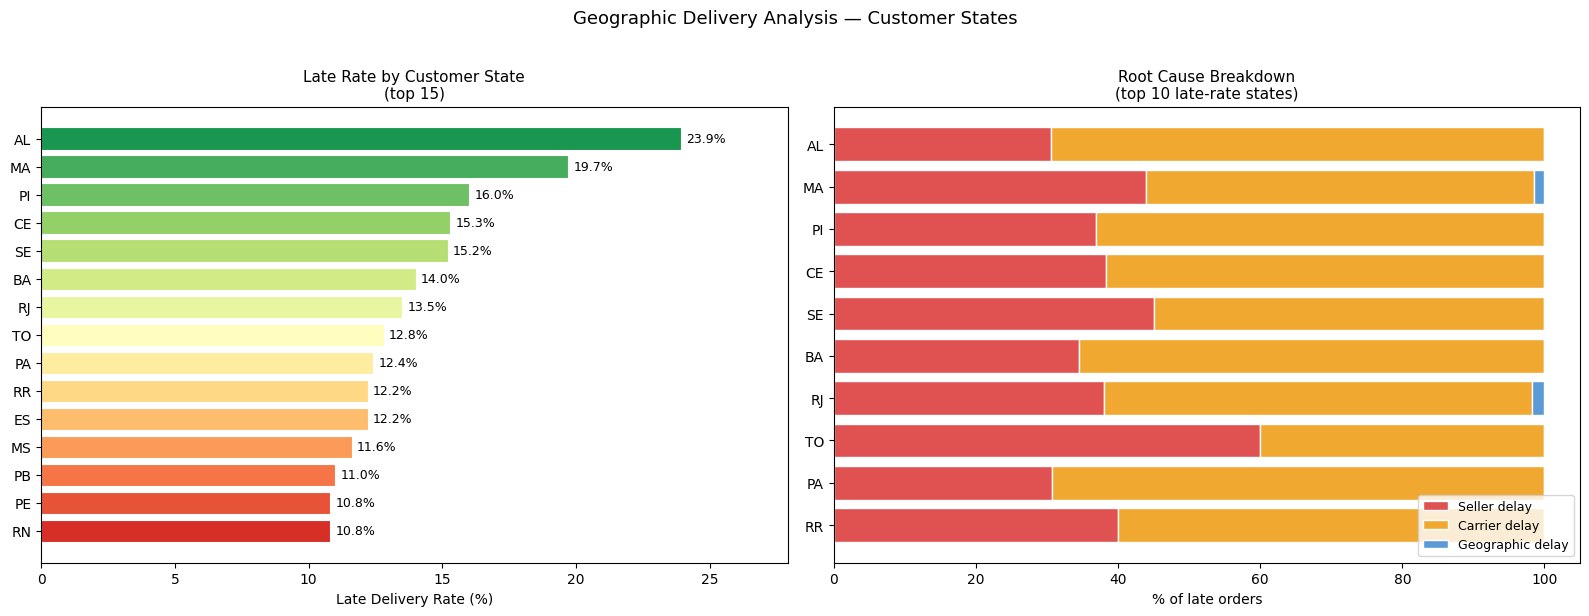

Saved


In [31]:
# Stacked bar chart — root cause breakdown by state
top_states = state_analysis.head(15).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: late rate by state
ax = axes[0]
colors_bar = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.9, len(top_states))
)
bars = ax.barh(
    top_states['customer_state'][::-1],
    top_states['late_rate_%'][::-1],
    color=colors_bar[::-1], edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, top_states['late_rate_%'][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_title('Late Rate by Customer State\n(top 15)', fontsize=11)
ax.set_xlim(0, top_states['late_rate_%'].max() + 4)

# Right: stacked root cause breakdown for top 10 states
ax2 = axes[1]
top10 = state_analysis.head(10).copy()
total_late = top10['seller_delay'] + top10['carrier_delay'] + top10['geographic_delay']
top10['seller_pct']    = top10['seller_delay']    / total_late * 100
top10['carrier_pct']   = top10['carrier_delay']   / total_late * 100
top10['geo_pct']       = top10['geographic_delay']/ total_late * 100

states = top10['customer_state'].tolist()[::-1]
y = np.arange(len(states))

s_vals = top10['seller_pct'].tolist()[::-1]
c_vals = top10['carrier_pct'].tolist()[::-1]
g_vals = top10['geo_pct'].tolist()[::-1]

ax2.barh(y, s_vals, color='#E05252', label='Seller delay',     edgecolor='white')
ax2.barh(y, c_vals, left=s_vals,    color='#F0A830', label='Carrier delay',    edgecolor='white')
ax2.barh(y, g_vals, left=[s+c for s,c in zip(s_vals,c_vals)],
         color='#5B9BD5', label='Geographic delay', edgecolor='white')

ax2.set_yticks(y)
ax2.set_yticklabels(states)
ax2.set_xlabel('% of late orders')
ax2.set_title('Root Cause Breakdown\n(top 10 late-rate states)', fontsize=11)
ax2.legend(loc='lower right', fontsize=9)
ax2.set_xlim(0, 105)

plt.suptitle('Geographic Delivery Analysis — Customer States', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS + '05_state_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

---
## Cell 6 — Map 3: Seller risk concentration map

Shows where Red and Amber tier vendors are physically located.

In [32]:
print(scorecard.columns.tolist())

['seller_id', 'seller_state', 'total_orders', 'otd_rate', 'late_rate', 'avg_processing_days', 'p75_processing_days', 'avg_carrier_days', 'avg_delay_days', 'sla_breach_rate', 'seller_delay_pct', 'carrier_delay_pct', 'geographic_delay_pct', 'dominant_cause', 'total_late', 'vendor_risk_score', 'risk_tier']


In [34]:
# Cell 6 — always rebuild seller_geo from scratch
sellers_raw = pd.read_csv(RAW + 'olist_sellers_dataset.csv')[['seller_id','seller_zip_code_prefix']]
scorecard_with_zip = scorecard.merge(sellers_raw, on='seller_id', how='left')

seller_geo = scorecard_with_zip.merge(
    geo_ref[['zip_prefix', 'lat', 'lng']],
    left_on='seller_zip_code_prefix',
    right_on='zip_prefix',
    how='left'
).dropna(subset=['lat', 'lng'])

print(f'Vendors with coordinates: {len(seller_geo):,}')
print(seller_geo['risk_tier'].value_counts().to_string())

Vendors with coordinates: 1,223
risk_tier
Green    855
Amber    245
Red      123


In [35]:
# Build seller risk map
seller_map = folium.Map(
    location=BRAZIL_CENTER,
    zoom_start=4,
    tiles='CartoDB positron'
)

TIER_CONFIG = {
    'Red':   {'color': '#E05252', 'radius': 8,  'opacity': 0.9, 'order': 3},
    'Amber': {'color': '#F0A830', 'radius': 6,  'opacity': 0.7, 'order': 2},
    'Green': {'color': '#4CAF50', 'radius': 4,  'opacity': 0.4, 'order': 1},
}

# Plot in order: Green first (background), Red last (foreground)
for tier in ['Green', 'Amber', 'Red']:
    config  = TIER_CONFIG[tier]
    tier_df = seller_geo[seller_geo['risk_tier'] == tier]

    for _, row in tier_df.iterrows():
        popup_text = (
            f"<b>Seller:</b> {row['seller_id'][:8]}...<br>"
            f"<b>State:</b> {row['seller_state']}<br>"
            f"<b>Score:</b> {row['vendor_risk_score']:.1f}<br>"
            f"<b>Tier:</b> {row['risk_tier']}<br>"
            f"<b>OTD Rate:</b> {row['otd_rate']:.1%}<br>"
            f"<b>SLA Breach:</b> {row['sla_breach_rate']:.1%}<br>"
            f"<b>Dominant Cause:</b> {row['dominant_cause']}"
        )
        folium.CircleMarker(
            location=[row['lat'], row['lng']],
            radius=config['radius'],
            color=config['color'],
            fill=True,
            fill_color=config['color'],
            fill_opacity=config['opacity'],
            popup=folium.Popup(popup_text, max_width=220),
            tooltip=f"{tier} | Score: {row['vendor_risk_score']:.0f}"
        ).add_to(seller_map)

# Legend
legend_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; background: white;
            padding: 12px 16px; border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.3); z-index: 9999;
            font-family: Arial; font-size: 12px;">
    <b style="font-size:13px;">Vendor Risk Tier</b><br><br>
    <span style="color:#E05252;">●</span> <b>Red</b> — High risk (bottom 10%)<br>
    <span style="color:#F0A830;">●</span> <b>Amber</b> — Watch (P10–P30)<br>
    <span style="color:#4CAF50;">●</span> <b>Green</b> — Reliable (top 70%)<br>
    <br><i style="color:#888;font-size:11px;">Click any dot for vendor details</i>
</div>
'''
seller_map.get_root().html.add_child(folium.Element(legend_html))

# Title
title_html2 = '''
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
            background: white; padding: 8px 16px; border-radius: 6px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.3); z-index: 9999;
            font-family: Arial; font-size: 14px; font-weight: bold; color: #333;">
    Vendor Risk Concentration Map
    <span style="font-weight:normal; font-size:11px; color:#888;"> (click dots for details)</span>
</div>
'''
seller_map.get_root().html.add_child(folium.Element(title_html2))

map_path2 = OUTPUTS + 'vendor_risk_map.html'
seller_map.save(map_path2)
print(f'Saved: vendor_risk_map.html')
print('Each dot = one vendor. Red dots are clickable — shows score, OTD rate, dominant cause.')

Saved: vendor_risk_map.html
Each dot = one vendor. Red dots are clickable — shows score, OTD rate, dominant cause.


In [36]:
# Preview inline
seller_map

---
## Cell 7 — Geographic delay deep dive

The 5.8% of delays classified as geographic need specific attention.  
Which customer states are most affected by structural geographic delays?

In [37]:
geo_delay_orders = orders[orders['root_cause'] == 'geographic_delay'].copy()

geo_by_state = (
    geo_delay_orders
    .groupby('customer_state')
    .agg(
        geo_delay_count = ('order_id',    'count'),
        avg_delay_days  = ('delay_days',  'mean'),
    )
    .reset_index()
    .sort_values('geo_delay_count', ascending=False)
)

# Merge with total orders for context
total_by_state = orders.groupby('customer_state')['order_id'].count().reset_index()
total_by_state.columns = ['customer_state', 'total_orders']
geo_by_state = geo_by_state.merge(total_by_state, on='customer_state')
geo_by_state['geo_delay_rate_%'] = (
    geo_by_state['geo_delay_count'] / geo_by_state['total_orders'] * 100
).round(2)

print('States with highest geographic delay concentration:')
print(geo_by_state.head(10).to_string(index=False))
print()
print('These states need delivery estimate buffers or surcharges — not vendor penalties.')

States with highest geographic delay concentration:
customer_state  geo_delay_count  avg_delay_days  total_orders  geo_delay_rate_%
            SP              387        1.854781         40493              0.96
            RJ               29        1.234966         12350              0.23
            MG                9        1.530338         11354              0.08
            PR                6        2.085909          4923              0.12
            SC                5        0.871160          3546              0.14
            RS                4        1.493814          5344              0.07
            MA                2        1.899253           717              0.28
            ES                2        1.143154          1995              0.10
            DF                2        3.309352          2080              0.10
            GO                1        0.790845          1957              0.05

These states need delivery estimate buffers or surcharges — not ven

---
## Cell 8 — Save all outputs and print final summary

In [38]:
# Save state analysis
state_analysis.to_csv(OUTPUTS + 'state_delivery_analysis.csv', index=False)
geo_by_state.to_csv(OUTPUTS + 'geographic_delay_by_state.csv', index=False)

print('All outputs saved:')
print('  delay_heatmap_customer.html  — customer late delivery heatmap')
print('  vendor_risk_map.html         — interactive vendor risk map')
print('  state_delivery_analysis.csv  — state-level metrics')
print('  geographic_delay_by_state.csv — geographic delay breakdown')
print()
print('PROJECT FULL FINDINGS SUMMARY')
print(f'  Dataset:          96,478 delivered orders')
print(f'  Overall late rate: 8.1%')
print()
print('Root cause split:')
print('  Seller delay:      43.9%  → vendor warnings needed')
print('  Carrier delay:     50.4%  → carrier SLA renegotiation')
print('  Geographic delay:   5.8%  → estimate buffers / surcharges')
print()
print('Vendor scorecard:')
print('  Green  (top 70%):  859 vendors — reliable')
print('  Amber  (P10-P30):  245 vendors — watch closely')
print('  Red    (bottom 10%): 123 vendors — immediate review')
print()
print('Key geographic finding:')
print('  SP = highest Red vendor concentration')
print('  Seller delay is dominant cause in Red tier')

All outputs saved:
  delay_heatmap_customer.html  — customer late delivery heatmap
  vendor_risk_map.html         — interactive vendor risk map
  state_delivery_analysis.csv  — state-level metrics
  geographic_delay_by_state.csv — geographic delay breakdown

PROJECT FULL FINDINGS SUMMARY
  Dataset:          96,478 delivered orders
  Overall late rate: 8.1%

Root cause split:
  Seller delay:      43.9%  → vendor warnings needed
  Carrier delay:     50.4%  → carrier SLA renegotiation
  Geographic delay:   5.8%  → estimate buffers / surcharges

Vendor scorecard:
  Green  (top 70%):  859 vendors — reliable
  Amber  (P10-P30):  245 vendors — watch closely
  Red    (bottom 10%): 123 vendors — immediate review

Key geographic finding:
  SP = highest Red vendor concentration
  Seller delay is dominant cause in Red tier


---
## Geospatial Summary

| Metric | Value |
|---|---|
| Highest late-rate customer state | AL |
| That state's late rate % | 23.9% |
| State with most geographic delays | SP |
| Vendors successfully mapped (with coordinates) | 1,224 of 1,227 |
| Do Red vendors cluster in specific regions? (Y/N) | Y |
